# scRNA-seq Interactive Agent Notebook

## 0. Setup

This notebook is the user interface for a general best-practice scRNA-seq/snRNA-seq agent workflow.

- Codex writes and reviews the project code and notebook structure.
- The pipeline script executes reproducible analysis steps.
- The server runs the analysis where the data live.
- The biology reviewer reviews summaries, tables, and plots, not raw data.

Run the setup cells first, then check that the server paths resolve before writing config or starting QC.

Intended usage loop: edit parameters -> write config -> run one stage -> generate plots -> inspect/review -> optionally adjust parameters and rerun.

In [23]:
from pathlib import Path
import os

DATASET_ID = "EC"
PROJECT_ROOT = Path("/mnt/12tb_dsk3/svitlana/scrna-agent")
PYTHON = Path("/mnt/12tb_dsk3/svitlana/sci-project-intership-2026/env_scanpy/bin/python")
DATA_ROOT = Path("/mnt/12tb_dsk3/svitlana/sci-project-intership-2026/data")
DATA_PATH = DATA_ROOT / f"{DATASET_ID}.h5ad"
RUN_ID = f"{DATASET_ID.lower()}_debug"
CONFIG_PATH = PROJECT_ROOT / "configs" / "pipeline.server.yaml"
SCRIPT_PATH = PROJECT_ROOT / "scripts" / "scrna_pipeline.py"
RESULTS_ROOT = PROJECT_ROOT / "results"

os.chdir(PROJECT_ROOT)

PROJECT_ROOT, PYTHON, DATA_ROOT, DATA_PATH, RUN_ID, CONFIG_PATH, SCRIPT_PATH, RESULTS_ROOT

(PosixPath('/mnt/12tb_dsk3/svitlana/scrna-agent'),
 PosixPath('/mnt/12tb_dsk3/svitlana/sci-project-intership-2026/env_scanpy/bin/python'),
 PosixPath('/mnt/12tb_dsk3/svitlana/sci-project-intership-2026/data'),
 PosixPath('/mnt/12tb_dsk3/svitlana/sci-project-intership-2026/data/EC.h5ad'),
 'ec_debug',
 PosixPath('/mnt/12tb_dsk3/svitlana/scrna-agent/configs/pipeline.server.yaml'),
 PosixPath('/mnt/12tb_dsk3/svitlana/scrna-agent/scripts/scrna_pipeline.py'),
 PosixPath('/mnt/12tb_dsk3/svitlana/scrna-agent/results'))

In [24]:
path_checks = {
    "PROJECT_ROOT exists": PROJECT_ROOT.exists(),
    "PYTHON exists": PYTHON.exists(),
    "DATA_PATH exists": DATA_PATH.exists(),
    "SCRIPT_PATH exists": SCRIPT_PATH.exists(),
    "CONFIG_PATH parent exists": CONFIG_PATH.parent.exists(),
    "RESULTS_ROOT exists": RESULTS_ROOT.exists(),
}

for label, ok in path_checks.items():
    print(f"{label}: {ok}")

PROJECT_ROOT exists: True
PYTHON exists: True
DATA_PATH exists: True
SCRIPT_PATH exists: True
CONFIG_PATH parent exists: True
RESULTS_ROOT exists: True


## 1. Editable Parameters

Change `DATASET_ID` to analyze another dataset or sample identifier, for example `EC`, `PFC`, or `HC`. After changing `DATASET_ID`, rerun the setup cell so `DATA_PATH` and `RUN_ID` update.

`debug_max_cells = 5000` is for testing. Use it until QC and downstream review look reasonable. A full run uses `debug_max_cells = None`.

PCA happens later inside preprocess, not in QC.

These parameters are collected here so the run is reproducible.  
If you change any value, rerun this cell and then rerun `write_config()` before executing pipeline steps.

In [25]:
# Analysis parameters used when write_config() creates configs/pipeline.server.yaml
use_harmony = True
harmony_batch_key = "individualID"
hvg_n_top_genes = 3000
hvg_flavor = "seurat"
scaling_max_value = 10
neighbors_n_neighbors = 15
neighbors_n_pcs = 30
leiden_resolution = 0.5
random_state = 42

# Use an integer for debug runs. Use None for full dataset runs.
debug_max_cells = 5000

## 2. Write config

This section writes `configs/pipeline.server.yaml` from the setup paths and editable parameters above.

The generated config:
- defines the dataset input
- stores all analysis parameters in one place
- makes runs reproducible
- allows the pipeline script to execute independently from the notebook

The config points to an `.h5ad` input on the server and uses timestamped run folders under `RESULTS_ROOT`.

If parameters are changed later, rerun:
1. the parameter cell
2. `write_config()`

before executing additional pipeline steps.

Harmony is optional and should only be enabled when batch correction is biologically justified.

Upper-tail MAD3 mitochondrial filtering is enabled by default. After reviewing the QC plots, confirm that the filtering does not appear overly aggressive for the current dataset before continuing.

In [26]:
import yaml


def write_config():
    config = {
        "project_name": f"scrna_{DATASET_ID.lower()}",
        "input": {
            "format": "h5ad",
            "path": str(DATA_PATH),
        },
        "output": {
            "processed_dir": "data/processed",
            "figures_dir": "reports/figures",
            "tables_dir": "reports/tables",
            "logs_dir": "logs",
        },
        "run": {
            "id": RUN_ID,
            "add_timestamp": True,
            "base_dir": str(RESULTS_ROOT.resolve()),
        },
        "qc": {
            "min_genes": 200,
            "min_cells": 10,
            "max_pct_mt": 8,
            "max_genes": None,
            "max_counts": None,
            "mt_gene_prefix": "MT-",
            "ribo_gene_prefixes": ["RPS", "RPL"],
            "hb_gene_pattern": "^HB[^(P)]",
            "mad_filter": {
                "enabled": True,
                "log1p_total_counts_nmads": 5,
                "log1p_n_genes_by_counts_nmads": 5,
                "pct_counts_mt_nmads": 3,
                "mt_direction": "upper",
            },
        },
        "normalization": {
            "target_sum": 10000,
            "log1p": True,
        },
        "scaling": {
            "max_value": scaling_max_value,
        },
        "hvg": {
            "n_top_genes": hvg_n_top_genes,
            "flavor": hvg_flavor,
            "batch_key": None,
        },
        "pca": {
            "n_comps": 50,
            "svd_solver": "arpack",
            "random_state": random_state,
        },
        "harmony": {
            "enabled": use_harmony,
            "batch_key": harmony_batch_key,
            "basis": "X_pca",
            "adjusted_basis": "X_pca_harmony",
        },
        "neighbors": {
            "n_neighbors": neighbors_n_neighbors,
            "n_pcs": neighbors_n_pcs,
        },
        "umap": {
            "random_state": random_state,
        },
        "clustering": {
            "method": "leiden",
            "resolution": leiden_resolution,
            "key_added": "leiden",
            "random_state": random_state,
        },
        "debug": {
            "max_cells": debug_max_cells,
            "random_state": random_state,
        },
        "markers": {
            "groupby": "leiden",
            "method": "wilcoxon",
            "n_genes": 100,
        },
    }

    CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)
    with CONFIG_PATH.open("w", encoding="utf-8") as handle:
        yaml.safe_dump(config, handle, sort_keys=False)
    return CONFIG_PATH

In [27]:
write_config()
print(CONFIG_PATH.read_text())

project_name: scrna_ec
input:
  format: h5ad
  path: /mnt/12tb_dsk3/svitlana/sci-project-intership-2026/data/EC.h5ad
output:
  processed_dir: data/processed
  figures_dir: reports/figures
  tables_dir: reports/tables
  logs_dir: logs
run:
  id: ec_debug
  add_timestamp: true
  base_dir: /mnt/12tb_dsk3/svitlana/scrna-agent/results
qc:
  min_genes: 200
  min_cells: 10
  max_pct_mt: 8
  max_genes: null
  max_counts: null
  mt_gene_prefix: MT-
  ribo_gene_prefixes:
  - RPS
  - RPL
  hb_gene_pattern: ^HB[^(P)]
  mad_filter:
    enabled: true
    log1p_total_counts_nmads: 5
    log1p_n_genes_by_counts_nmads: 5
    pct_counts_mt_nmads: 3
    mt_direction: upper
normalization:
  target_sum: 10000
  log1p: true
scaling:
  max_value: 10
hvg:
  n_top_genes: 3000
  flavor: seurat
  batch_key: null
pca:
  n_comps: 50
  svd_solver: arpack
  random_state: 42
harmony:
  enabled: true
  batch_key: individualID
  basis: X_pca
  adjusted_basis: X_pca_harmony
neighbors:
  n_neighbors: 15
  n_pcs: 30
umap:

## 3. Helper Functions

Most helper functions are defined here so later sections stay focused on running and reviewing workflow stages.

In [28]:
import json
import subprocess
import pandas as pd


def run_step(step, context=None):
    command = [str(PYTHON), str(SCRIPT_PATH), "--config", str(CONFIG_PATH), "--step", step]
    if context is not None:
        command.extend(["--plot-context", context])
    subprocess.run(command, check=True)


def get_latest_run():
    run_dirs = sorted(
        [path for path in RESULTS_ROOT.glob(f"{RUN_ID}_*") if path.is_dir()],
        key=lambda path: path.name,
    )
    if not run_dirs:
        raise FileNotFoundError(f"No run folders found for {RUN_ID} under {RESULTS_ROOT}")
    return run_dirs[-1]


def show_workflow_status():
    try:
        latest_run = get_latest_run()
    except FileNotFoundError as exc:
        print(f"No run folder found yet: {exc}")
        return None

    state_path = latest_run / "workflow_state.json"
    if state_path.exists():
        with state_path.open("r", encoding="utf-8") as handle:
            state = json.load(handle)
        status = pd.DataFrame([
            {
                "current_step": state.get("current_step"),
                "completed_steps": ", ".join(state.get("completed_steps", [])),
                "latest_h5ad": state.get("latest_h5ad"),
                "available_tables": len(state.get("available_tables", [])),
                "available_figures": len(state.get("available_figures", [])),
            }
        ])
        print(f"Latest run: {latest_run}")
        display(status)
        return None

    expected_paths = [
        latest_run / "data" / "qc.h5ad",
        latest_run / "data" / "preprocessed.h5ad",
        latest_run / "data" / "harmony.h5ad",
        latest_run / "data" / "clustered.h5ad",
        latest_run / "data" / "markers.h5ad",
        latest_run / "tables" / "qc_filtering_summary.csv",
        latest_run / "tables" / "harmony_summary.csv",
        latest_run / "tables" / "clustering_summary.csv",
        latest_run / "tables" / "markers_summary.csv",
    ]
    status = pd.DataFrame([
        {
            "artifact": path.name,
            "path": str(path.relative_to(latest_run)),
            "exists": path.exists(),
        }
        for path in expected_paths
    ])
    print(f"Latest run: {latest_run}")
    display(status)
    return None


def suggest_next_action():
    try:
        latest_run = get_latest_run()
    except FileNotFoundError as exc:
        print(f"No run folder found yet: {exc}")
        return None

    state_path = latest_run / "workflow_state.json"
    if state_path.exists():
        with state_path.open("r", encoding="utf-8") as handle:
            state = json.load(handle)
        completed_stages = state.get("completed_steps", [])
        latest_completed = completed_stages[-1] if completed_stages else "none"
        completed = set(completed_stages)
    else:
        stage_paths = {
            "qc": latest_run / "data" / "qc.h5ad",
            "preprocess": latest_run / "data" / "preprocessed.h5ad",
            "harmony": latest_run / "data" / "harmony.h5ad",
            "cluster": latest_run / "data" / "clustered.h5ad",
            "markers": latest_run / "data" / "markers.h5ad",
        }
        completed_stages = [stage for stage, path in stage_paths.items() if path.exists()]
        latest_completed = completed_stages[-1] if completed_stages else "none"
        completed = set(completed_stages)

    if "markers" in completed:
        next_stage = "review workflow / compare runs / annotation review"
        suggested_command = "Use review workflow cells; compare runs or start annotation review."
    elif "cluster" in completed:
        next_stage = "markers"
        suggested_command = 'run_step("markers")'
    elif "harmony" in completed:
        next_stage = "cluster"
        suggested_command = 'run_step("cluster")'
    elif "preprocess" in completed:
        next_stage = "harmony or clustering"
        suggested_command = 'run_step("harmony") or run_step("cluster")'
    elif "qc" in completed:
        next_stage = "preprocess"
        suggested_command = 'run_step("preprocess")'
    else:
        next_stage = "qc"
        suggested_command = 'run_step("qc")'

    print(f"Latest run: {latest_run}")
    print(f"Latest completed stage: {latest_completed}")
    print(f"Available next stage: {next_stage}")
    print(f"Suggested command: {suggested_command}")
    return None


def show_qc_summary():
    latest_run = get_latest_run()
    qc_summary_path = latest_run / "tables" / "qc_filtering_summary.csv"
    if not qc_summary_path.exists():
        raise FileNotFoundError(f"QC summary not found: {qc_summary_path}")
    qc_summary = pd.read_csv(qc_summary_path)
    display(qc_summary)
    return None


def show_qc_figures():
    latest_run = get_latest_run()
    figures_dir = latest_run / "figures"
    expected_paths = [
        figures_dir / "violin_qc.png",
        figures_dir / "scatter_qc_counts_vs_mt.png",
        figures_dir / "qc_scatter_counts_vs_genes_mt.png",
    ]
    expected_paths.extend(sorted(figures_dir.glob("qc_hist*.png")) if figures_dir.exists() else [])

    print(f"Latest run: {latest_run}")
    print("QC figure paths:")
    for path in expected_paths:
        status = "FOUND" if path.exists() else "MISSING"
        print(f"- [{status}] {path}")

    #return expected_paths


def show_qc_plots():
    from IPython.display import Image, display

    latest_run = get_latest_run()
    figures_dir = latest_run / "figures"
    qc_plots = [
        ("QC violin plot", figures_dir / "violin_qc.png"),
        ("Counts vs mitochondrial percentage", figures_dir / "scatter_qc_counts_vs_mt.png"),
        ("Counts vs genes colored by mitochondrial percentage", figures_dir / "qc_scatter_counts_vs_genes_mt.png"),
        ("Mitochondrial percentage histogram", figures_dir / "qc_hist_pct_counts_mt.png"),
        ("Genes detected histogram", figures_dir / "qc_hist_n_genes_by_counts.png"),
        ("Total counts histogram", figures_dir / "qc_hist_total_counts.png"),
    ]

    for title, path in qc_plots:
        print(f"\n=== {title} ===")
        if path.exists():
            display(Image(filename=str(path)))
        else:
            print(f"WARNING: missing QC figure: {path}")


def show_preprocess_summary():
    import scanpy as sc

    latest_run = get_latest_run()
    preprocessed_path = latest_run / "data" / "preprocessed.h5ad"
    if not preprocessed_path.exists():
        raise FileNotFoundError(f"Preprocessed AnnData not found: {preprocessed_path}")
    adata = sc.read_h5ad(preprocessed_path)
    hvg_count = int(adata.var["highly_variable"].sum()) if "highly_variable" in adata.var else None
    x_pca = adata.obsm.get("X_pca")
    summary = pd.DataFrame([
        {
            "cells": adata.n_obs,
            "genes": adata.n_vars,
            "highly_variable_genes": hvg_count,
            "obsm_keys": ", ".join(adata.obsm.keys()),
            "has_X_pca": x_pca is not None,
            "X_pca_shape": str(x_pca.shape) if x_pca is not None else "",
        }
    ])
    display(summary)
    return None


def show_preprocess_figures():
    latest_run = get_latest_run()
    figures_dir = latest_run / "figures"
    expected_paths = [
        figures_dir / "hvg_plot.png",
        figures_dir / "pca_scree.png",
        figures_dir / "pca_scatter_qc_metrics.png",
    ]

    print(f"Latest run: {latest_run}")
    print("Preprocess figure paths:")
    for path in expected_paths:
        status = "FOUND" if path.exists() else "MISSING"
        print(f"- [{status}] {path}")


def show_preprocess_plots():
    from IPython.display import Image, display

    latest_run = get_latest_run()
    figures_dir = latest_run / "figures"
    preprocess_plots = [
        ("Highly variable genes", figures_dir / "hvg_plot.png"),
        ("PCA variance explained", figures_dir / "pca_scree.png"),
        ("PCA colored by QC metrics", figures_dir / "pca_scatter_qc_metrics.png"),
    ]

    for title, path in preprocess_plots:
        print(f"\n=== {title} ===")
        if path.exists():
            display(Image(filename=str(path)))
        else:
            print(f"WARNING: missing preprocess figure: {path}")

def show_harmony_summary():
    latest_run = get_latest_run()
    summary_path = latest_run / "tables" / "harmony_summary.csv"
    if not summary_path.exists():
        raise FileNotFoundError(f"Harmony summary not found: {summary_path}")
    summary = pd.read_csv(summary_path)
    display(summary)
    return None


def _harmony_plot_paths():
    latest_run = get_latest_run()
    figures_dir = latest_run / "figures"
    if not figures_dir.exists():
        return []
    tokens = ["harmony", "integration", "batch"]
    return sorted(
        path for path in figures_dir.glob("*.png")
        if any(token in path.name.lower() for token in tokens)
    )


def show_harmony_figures():
    latest_run = get_latest_run()
    plot_paths = _harmony_plot_paths()
    print(f"Latest run: {latest_run}")
    if not plot_paths:
        print("No Harmony-related plot files found. Harmony plotting may be added later.")
        return None
    print("Harmony figure paths:")
    for path in plot_paths:
        print(f"- {path}")
    return None


def show_harmony_plots():
    from IPython.display import Image, display

    plot_paths = _harmony_plot_paths()
    if not plot_paths:
        print("No Harmony plots are currently generated.")
        return None
    for path in plot_paths:
        print(f"\n=== {path.name} ===")
        display(Image(filename=str(path)))
    return None

def show_clustering_summary():
    latest_run = get_latest_run()
    summary_path = latest_run / "tables" / "clustering_summary.csv"
    if not summary_path.exists():
        raise FileNotFoundError(f"Clustering summary not found: {summary_path}")
    summary = pd.read_csv(summary_path)
    display(summary)
    return None


def show_clustering_figures():
    latest_run = get_latest_run()
    figures_dir = latest_run / "figures"
    expected_paths = [
        figures_dir / "umap_qc_counts_genes.png",
        figures_dir / "umap_leiden.png",
        figures_dir / "umap_leiden_numbered.png",
        figures_dir / "umap_metadata_panel.png",
    ]
    print(f"Latest run: {latest_run}")
    print("Clustering figure paths:")
    for path in expected_paths:
        status = "FOUND" if path.exists() else "MISSING"
        print(f"- [{status}] {path}")
    return None


def show_clustering_plots():
    from IPython.display import Image, display

    latest_run = get_latest_run()
    figures_dir = latest_run / "figures"
    clustering_plots = [
        ("UMAP colored by counts and genes", figures_dir / "umap_qc_counts_genes.png"),
        ("UMAP colored by Leiden clusters", figures_dir / "umap_leiden.png"),
        ("UMAP with Leiden labels on data", figures_dir / "umap_leiden_numbered.png"),
        ("UMAP metadata sanity-check panel", figures_dir / "umap_metadata_panel.png"),
    ]
    for title, path in clustering_plots:
        print(f"\n=== {title} ===")
        if path.exists():
            display(Image(filename=str(path)))
        else:
            print(f"WARNING: optional clustering figure is missing: {path}")
    return None

def show_marker_summary():
    latest_run = get_latest_run()
    summary_path = latest_run / "tables" / "markers_summary.csv"
    if not summary_path.exists():
        raise FileNotFoundError(f"Marker summary not found: {summary_path}")
    summary = pd.read_csv(summary_path)
    display(summary)
    return None


def show_marker_table(n=50):
    latest_run = get_latest_run()
    marker_table_path = latest_run / "tables" / "cluster_markers.csv"
    if not marker_table_path.exists():
        raise FileNotFoundError(f"Marker table not found: {marker_table_path}")
    marker_table = pd.read_csv(marker_table_path)
    display(marker_table.head(n))
    return None


def show_marker_figures():
    latest_run = get_latest_run()
    figures_dir = latest_run / "figures"
    expected_paths = [
        figures_dir / "marker_dotplot_top_genes.png",
    ]
    print(f"Latest run: {latest_run}")
    print("Marker figure paths:")
    for path in expected_paths:
        status = "FOUND" if path.exists() else "MISSING"
        print(f"- [{status}] {path}")
    return None


def show_marker_plots():
    from IPython.display import Image, display

    latest_run = get_latest_run()
    figures_dir = latest_run / "figures"
    marker_plots = [
        ("Marker dotplot top genes", figures_dir / "marker_dotplot_top_genes.png"),
    ]
    for title, path in marker_plots:
        print(f"\n=== {title} ===")
        if path.exists():
            display(Image(filename=str(path)))
        else:
            print(f"WARNING: optional marker figure is missing: {path}")
    return None

def create_review_packet(step):
    latest_run = get_latest_run()
    packet_path = latest_run / "biology_review_packet.md"
    tables_dir = latest_run / "tables"
    figures_dir = latest_run / "figures"
    data_dir = latest_run / "data"

    qc_summary_path = tables_dir / "qc_filtering_summary.csv"
    harmony_summary_path = tables_dir / "harmony_summary.csv"
    clustering_summary_path = tables_dir / "clustering_summary.csv"
    markers_summary_path = tables_dir / "markers_summary.csv"
    marker_table_path = tables_dir / "cluster_markers.csv"
    all_figure_paths = sorted(figures_dir.glob("*.png")) if figures_dir.exists() else []
    h5ad_paths = sorted(data_dir.glob("*.h5ad")) if data_dir.exists() else []
    latest_h5ad = h5ad_paths[-1] if h5ad_paths else None
    step_key = str(step).lower()
    if step_key == "qc":
        figure_paths = [
            path for path in all_figure_paths
            if path.name in {
                "violin_qc.png",
                "scatter_qc_counts_vs_mt.png",
                "qc_scatter_counts_vs_genes_mt.png",
            } or path.name.startswith("qc_hist_")
        ]
    elif step_key == "preprocess":
        figure_paths = [
            path for path in all_figure_paths
            if path.name in {"hvg_plot.png", "pca_scree.png", "pca_scatter_qc_metrics.png"}
        ]
    elif step_key == "harmony":
        figure_paths = [
            path for path in all_figure_paths
            if any(token in path.name.lower() for token in ["harmony", "integration", "batch"])
        ]
    elif step_key in {"cluster", "clustering"}:
        figure_paths = [
            path for path in all_figure_paths
            if path.name in {"umap_qc_counts_genes.png", "umap_leiden.png", "umap_leiden_numbered.png", "umap_metadata_panel.png"}
        ]
    elif step_key == "markers":
        figure_paths = [
            path for path in all_figure_paths
            if path.name in {"marker_dotplot_top_genes.png"}
        ]
    else:
        figure_paths = all_figure_paths
    expected_h5ad_by_step = {
        "qc": data_dir / "qc.h5ad",
        "preprocess": data_dir / "preprocessed.h5ad",
        "harmony": data_dir / "harmony.h5ad",
        "cluster": data_dir / "clustered.h5ad",
        "clustering": data_dir / "clustered.h5ad",
        "markers": data_dir / "markers.h5ad",
        "plots": data_dir / "plots.h5ad",
    }
    expected_h5ad = expected_h5ad_by_step.get(step_key)
    selected_h5ad = expected_h5ad if expected_h5ad is not None and expected_h5ad.exists() else latest_h5ad
    if step_key == "markers" and expected_h5ad is not None and not expected_h5ad.exists():
        clustered_h5ad = data_dir / "clustered.h5ad"
        selected_h5ad = clustered_h5ad if clustered_h5ad.exists() else latest_h5ad
    h5ad_warning = None
    if expected_h5ad is not None and not expected_h5ad.exists():
        if step_key == "markers":
            h5ad_warning = f"Expected h5ad for step '{step}' was missing: `{expected_h5ad}`. Falling back to clustered h5ad if available."
        else:
            h5ad_warning = f"Expected h5ad for step '{step}' was missing: `{expected_h5ad}`. Falling back to latest available h5ad."

    lines = []
    lines.append("# Biology Review Packet")
    lines.append("")
    lines.append(f"- Review step: `{step}`")
    lines.append(f"- Run folder: `{latest_run}`")
    lines.append(f"- Config path: `{CONFIG_PATH}`")
    lines.append("")
    lines.append("## Current Parameters")
    lines.append(f"- DATASET_ID: `{DATASET_ID}`")
    lines.append(f"- RUN_ID: `{RUN_ID}`")
    lines.append(f"- use_harmony: `{use_harmony}`")
    lines.append(f"- harmony_batch_key: `{harmony_batch_key}`")
    lines.append(f"- neighbors_n_neighbors: `{neighbors_n_neighbors}`")
    lines.append(f"- neighbors_n_pcs: `{neighbors_n_pcs}`")
    lines.append(f"- hvg_n_top_genes: `{hvg_n_top_genes}`")
    lines.append(f"- hvg_flavor: `{hvg_flavor}`")
    lines.append(f"- leiden_resolution: `{leiden_resolution}`")
    lines.append(f"- random_state: `{random_state}`")
    lines.append(f"- debug_max_cells: `{debug_max_cells}`")
    lines.append("")

    lines.append("## QC Summary")
    if qc_summary_path.exists():
        lines.append(pd.read_csv(qc_summary_path).to_markdown(index=False))
    else:
        lines.append("QC summary not available.")
    lines.append("")

    if step_key == "harmony":
        lines.append("## Harmony Summary")
        if harmony_summary_path.exists():
            lines.append(pd.read_csv(harmony_summary_path).to_markdown(index=False))
        else:
            lines.append("Harmony summary not available.")
        lines.append("")

    if step_key in {"cluster", "clustering"}:
        lines.append("## Clustering Summary")
        if clustering_summary_path.exists():
            lines.append(pd.read_csv(clustering_summary_path).to_markdown(index=False))
        else:
            lines.append("Clustering summary not available.")
        lines.append("")

    if step_key == "markers":
        lines.append("## Marker Summary")
        if markers_summary_path.exists():
            lines.append(pd.read_csv(markers_summary_path).to_markdown(index=False))
        else:
            lines.append("Marker summary not available.")
        lines.append("")

    lines.append("## Latest AnnData Summary")
    if h5ad_warning is not None:
        lines.append(f"WARNING: {h5ad_warning}")
    if selected_h5ad is not None:
        try:
            import scanpy as sc

            adata = sc.read_h5ad(selected_h5ad)
            lines.append(f"- Latest h5ad: `{selected_h5ad}`")
            lines.append(f"- Cells: `{adata.n_obs}`")
            lines.append(f"- Genes: `{adata.n_vars}`")
            obs_columns = list(adata.obs.columns)
            shown_obs_columns = obs_columns[:25]
            lines.append(f"- obs columns (showing first {len(shown_obs_columns)} of {len(obs_columns)}): " + ", ".join(f"`{col}`" for col in shown_obs_columns))
            if step_key in {"preprocess", "harmony", "cluster", "clustering", "markers"}:
                hvg_count = int(adata.var["highly_variable"].sum()) if "highly_variable" in adata.var else "not available"
                x_pca = adata.obsm.get("X_pca")
                lines.append(f"- highly variable genes: `{hvg_count}`")
                lines.append(f"- raw present: `{adata.raw is not None}`")
                lines.append(f"- X_pca present: `{x_pca is not None}`")
                lines.append(f"- X_pca shape: `{x_pca.shape if x_pca is not None else 'not available'}`")
                if step_key in {"harmony", "cluster", "clustering", "markers"}:
                    x_pca_harmony = adata.obsm.get("X_pca_harmony")
                    lines.append(f"- X_pca_harmony present: `{x_pca_harmony is not None}`")
                    lines.append(f"- X_pca_harmony shape: `{x_pca_harmony.shape if x_pca_harmony is not None else 'not available'}`")
                if step_key in {"cluster", "clustering", "markers"}:
                    x_umap = adata.obsm.get("X_umap")
                    clustering_key = "leiden"
                    lines.append(f"- X_umap present: `{x_umap is not None}`")
                    lines.append(f"- X_umap shape: `{x_umap.shape if x_umap is not None else 'not available'}`")
                    lines.append(f"- Leiden key present: `{clustering_key in adata.obs}`")
                    if clustering_key in adata.obs:
                        cluster_sizes = adata.obs[clustering_key].astype(str).value_counts().sort_index()
                        preview = "; ".join(f"{cluster}:{count}" for cluster, count in cluster_sizes.head(10).items())
                        if len(cluster_sizes) > 10:
                            preview += f"; ... ({len(cluster_sizes)} total)"
                        lines.append(f"- number of clusters: `{len(cluster_sizes)}`")
                        lines.append(f"- cluster sizes preview: `{preview}`")
            lines.append("- obsm keys: " + ", ".join(f"`{key}`" for key in adata.obsm.keys()))
            lines.append("- layers: " + ", ".join(f"`{key}`" for key in adata.layers.keys()))
        except Exception as exc:
            lines.append(f"Latest h5ad found at `{selected_h5ad}`, but summary failed: `{exc}`")
    else:
        lines.append("Latest h5ad not available.")
    lines.append("")

    lines.append("## Marker Table")
    if marker_table_path.exists():
        marker_table = pd.read_csv(marker_table_path)
        if step_key == "markers" and "cluster" in marker_table.columns:
            preview = marker_table.groupby("cluster", sort=False).head(5)
        else:
            preview = marker_table.head(50)
        lines.append(preview.to_markdown(index=False))
    else:
        lines.append("Marker table not available for this step.")
    lines.append("")

    lines.append("## Figure Files")
    if figure_paths:
        lines.extend(f"- `{path}`" for path in figure_paths)
    else:
        lines.append("Figure files not available for this step.")
    lines.append("")
    lines.append("This packet intentionally excludes raw expression matrix data.")

    packet_path.write_text("\n".join(lines), encoding="utf-8")
    return packet_path

from IPython.display import Markdown, display

def print_reviewer_prompt(step):
    packet_path = create_review_packet(step)
    packet_text = packet_path.read_text(encoding="utf-8")
    step_guidance = ""
    if step == "qc":
        step_guidance = """
## QC Review Guidance

Please evaluate:

- Whether QC filtering appears overly aggressive or too permissive.
- Whether mitochondrial filtering looks biologically reasonable.
- Whether QC distributions suggest technical artifacts.
- Whether the retained cell count looks reasonable.
- Whether preprocessing can safely proceed.
""".strip()
    elif step == "preprocess":
        step_guidance = """
## Preprocess Review Guidance

Please evaluate:

- Whether normalization and log1p look appropriate.
- Whether HVG selection looks reasonable.
- Whether PCA variance structure looks defensible.
- Whether technical effects remain visible in PCA.
- Whether Harmony or clustering can safely proceed.
""".strip()
    elif step == "harmony":
        step_guidance = """
## Harmony Review Guidance

Please evaluate:

- Whether Harmony was justified for this dataset.
- Whether the selected batch key is appropriate.
- Whether the batch key might encode biological or clinical variation.
- Whether Harmony ran or was correctly skipped.
- Whether overcorrection risk should be checked before clustering.
- Whether clustering should use X_pca_harmony or original X_pca.
""".strip()
    elif step in {"cluster", "clustering"}:
        step_guidance = """
## Clustering Review Guidance

Please evaluate:

- Whether UMAP structure looks plausible.
- Whether Leiden resolution appears too coarse or too granular.
- Whether clusters appear driven by QC metrics.
- Whether Harmony may have overcorrected or undercorrected.
- Whether neighbor graph parameters should be adjusted.
- Whether Leiden resolution should be increased or decreased.
- Whether marker analysis can safely proceed.
""".strip()
    elif step == "markers":
        step_guidance = """
## Marker Review Guidance

Please evaluate:

- Whether marker genes look biologically plausible.
- Whether clusters appear well-separated by markers.
- Whether any clusters look low-quality, doublet-like, or mixed.
- Whether Leiden resolution should be adjusted.
- Whether manual annotation can be considered later.
- Whether any cluster should be merged, split, or rechecked.
""".strip()

    prompt = f"""
Use prompts/biology_reviewer.md as your reviewer instructions.

Please review this single-cell run using only the packet content below and any plots/screenshots I provide. Do not access data/ or inspect h5ad files directly unless I explicitly allow it.

{step_guidance}

{packet_text}
""".strip()

    from IPython.display import Markdown, display

    print(prompt)

In [29]:
show_workflow_status()

Latest run: /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260512_122042


,artifact,path,exists
0,qc.h5ad,data/qc.h5ad,True
1,preprocessed.h5ad,data/preprocessed.h5ad,False
2,harmony.h5ad,data/harmony.h5ad,False
3,clustered.h5ad,data/clustered.h5ad,False
4,markers.h5ad,data/markers.h5ad,False
5,qc_filtering_summary.csv,tables/qc_filtering_summary.csv,True
6,harmony_summary.csv,tables/harmony_summary.csv,False
7,clustering_summary.csv,tables/clustering_summary.csv,False
8,markers_summary.csv,tables/markers_summary.csv,False


In [30]:
suggest_next_action()

Latest run: /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260512_122042
Latest completed stage: qc
Available next stage: preprocess
Suggested command: run_step("preprocess")


## 4. QC

QC loads the `.h5ad`, computes QC metrics, applies filters, and saves `qc.h5ad`.

QC plots should be reviewed before preprocessing. They help decide whether the filtering thresholds and mitochondrial structure look reasonable before normalization, HVG selection, PCA, Harmony, clustering, or marker analysis.

Expected outputs:

- `results/<RUN_ID>_<timestamp>/data/qc.h5ad`
- `results/<RUN_ID>_<timestamp>/tables/qc_filtering_summary.csv`
- `results/<RUN_ID>_<timestamp>/figures/violin_qc.png`
- `results/<RUN_ID>_<timestamp>/figures/scatter_qc_counts_vs_mt.png`
- `results/<RUN_ID>_<timestamp>/figures/qc_scatter_counts_vs_genes_mt.png`
- `results/<RUN_ID>_<timestamp>/figures/qc_hist_*.png`

Workflow for this section:

1. Run QC.
2. Generate QC plots.
3. Show the QC summary and QC figure paths.
4. Create the reviewer packet.
5. Print the reviewer prompt.

The reviewer should inspect QC distributions, mitochondrial-content structure, and filtering impact before preprocess. Ask whether the thresholds look defensible before continuing.

In [31]:
# run qc
run_step("qc")

2026-05-12 12:23:09 INFO Running step 'qc' in /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260512_122309
2026-05-12 12:23:09 INFO Loading h5ad input from /mnt/12tb_dsk3/svitlana/sci-project-intership-2026/data/EC.h5ad
2026-05-12 12:23:10 INFO Debug mode selected 5000 of 221493 cells using random_state=42.
2026-05-12 12:23:11 INFO Writing qc intermediate to /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260512_122309/data/qc.h5ad


Generate QC plots immediately after QC and before preprocess. Important files for review include `violin_qc.png`, `scatter_qc_counts_vs_mt.png`, and `qc_hist_*.png`.

At this stage, UMAP plots are expected to be unavailable because preprocessing, neighbors, and embedding have not been run yet.

In [32]:
run_step("plots", context="qc")

2026-05-12 12:23:18 INFO Running step 'plots' in /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260512_122309
2026-05-12 12:23:18 INFO Loading qc plotting input from /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260512_122309/data/qc.h5ad
2026-05-12 12:23:19 INFO Writing plots intermediate to /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260512_122309/data/plots.h5ad


In [33]:
latest_run = get_latest_run()
state_path = latest_run / "workflow_state.json"
print(state_path)
print(state_path.exists())

/mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260512_122309/workflow_state.json
True


Review the QC summary and figure paths before creating the reviewer packet. The reviewer should inspect QC distributions and mitochondrial structure before preprocess.

In [9]:
show_qc_summary()

,sample_id,cells_before_filtering,cells_after_filtering,cells_removed,min_genes,min_cells,max_pct_mt,max_genes,max_counts,mad_filter_enabled,log1p_total_counts_nmads,log1p_n_genes_by_counts_nmads,pct_counts_mt_nmads,mt_direction
0,all,5000,4255,745,200,10,8,NaN,NaN,True,5,5,3,upper


In [10]:
show_qc_figures()

Latest run: /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408
QC figure paths:
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/figures/violin_qc.png
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/figures/scatter_qc_counts_vs_mt.png
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/figures/qc_scatter_counts_vs_genes_mt.png
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/figures/qc_hist_n_genes_by_counts.png
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/figures/qc_hist_pct_counts_hb.png
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/figures/qc_hist_pct_counts_mt.png
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/figures/qc_hist_pct_counts_ribo.png
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/figures/qc_hist_total_counts

### QC Plot Review

Visually inspect these QC plots before preprocessing.

Look for:
- unusual QC distributions
- excessive mitochondrial structure
- evidence of low-quality cells
- potential over-filtering or under-filtering
- unexpected count or gene-complexity tails

Confirm that the QC thresholds appear biologically and technically defensible before continuing to preprocess.

Screenshots of these plots can be provided to the biology reviewer along with the reviewer packet.


=== QC violin plot ===


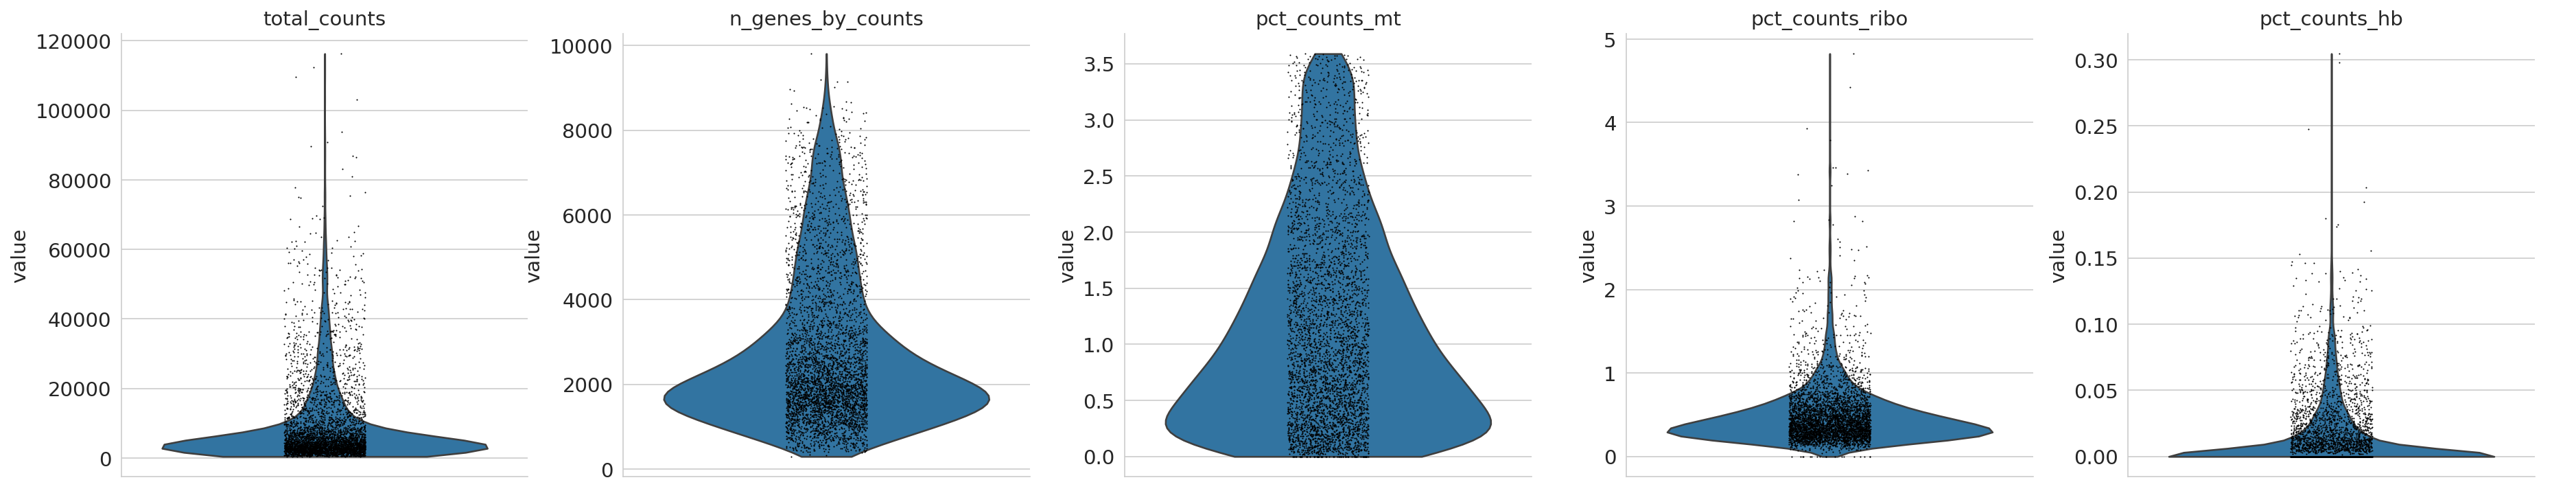


=== Counts vs mitochondrial percentage ===


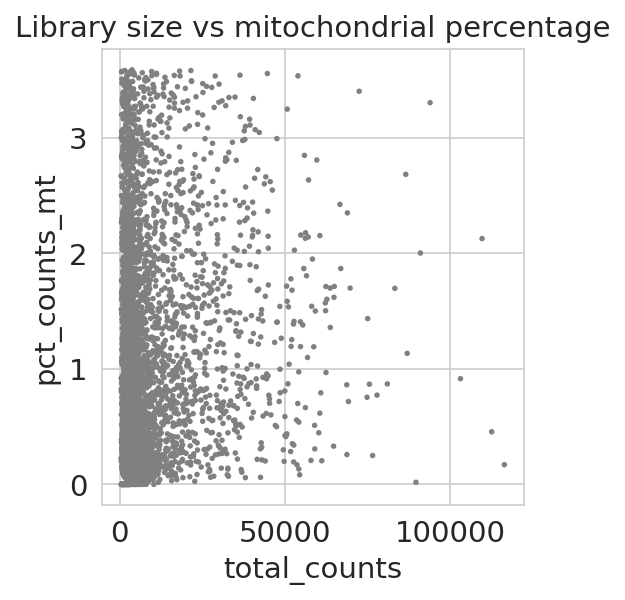


=== Counts vs genes colored by mitochondrial percentage ===


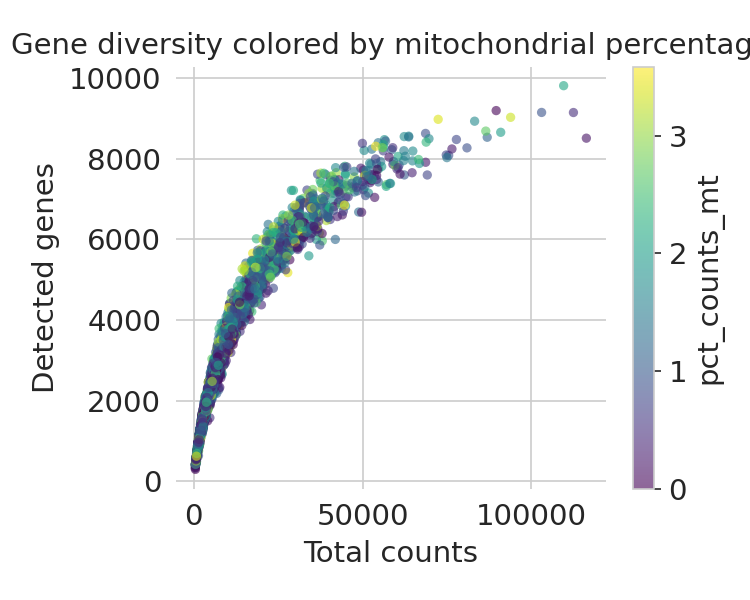


=== Mitochondrial percentage histogram ===


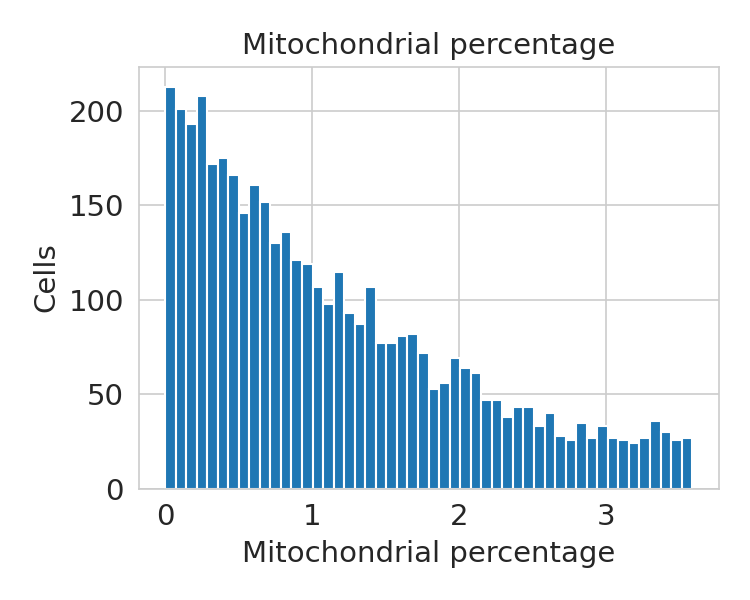


=== Genes detected histogram ===


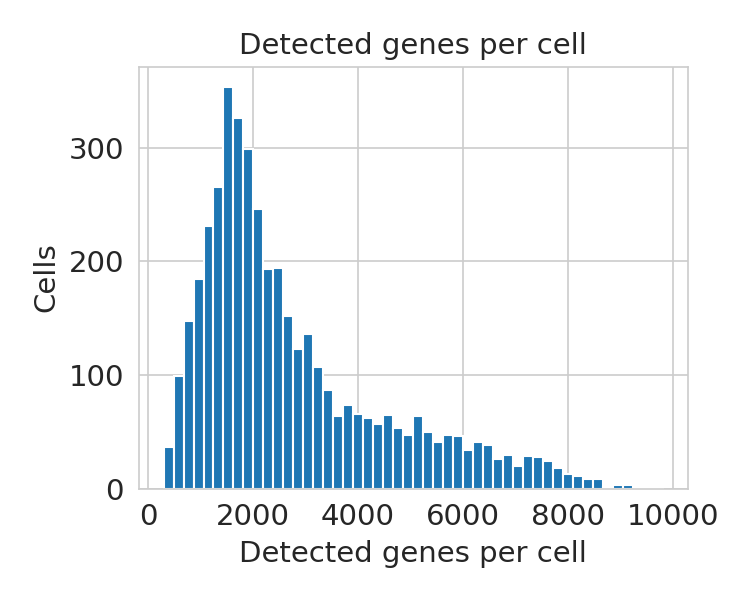


=== Total counts histogram ===


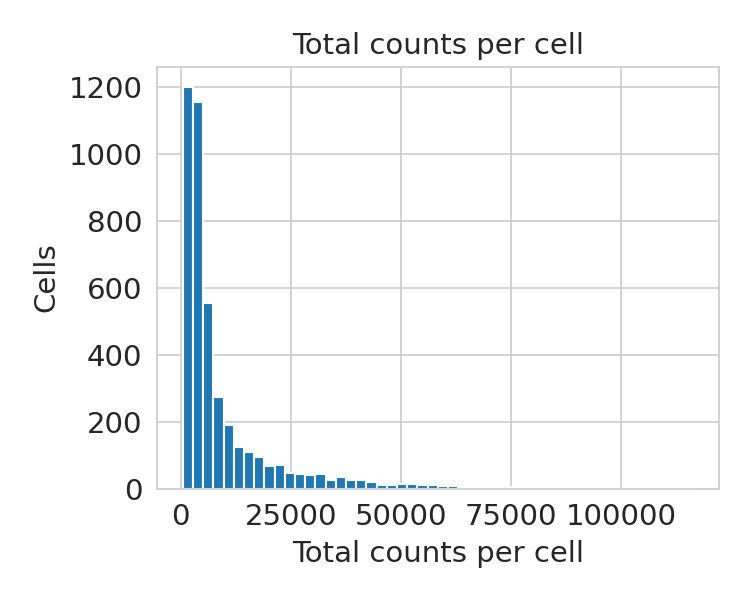

In [11]:
show_qc_plots()

### Create Reviewer Packet

Generate a compact review packet containing:
- QC filtering summary
- current analysis parameters
- AnnData structural summary
- figure file references
- optional marker previews if available

The packet intentionally excludes raw expression matrices.

In [12]:
create_review_packet("qc")

PosixPath('/mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/biology_review_packet.md')

### Reviewer Prompt

Print the final reviewer prompt with the review packet embedded inline.

The biology reviewer should use:
- the packet content
- QC summaries
- QC plots/screenshots

and should not inspect raw `.h5ad` files unless explicitly allowed.

In [13]:
print_reviewer_prompt("qc")

Use prompts/biology_reviewer.md as your reviewer instructions.

Please review this single-cell run using only the packet content below and any plots/screenshots I provide. Do not access data/ or inspect h5ad files directly unless I explicitly allow it.

## QC Review Guidance

Please evaluate:

- Whether QC filtering appears overly aggressive or too permissive.
- Whether mitochondrial filtering looks biologically reasonable.
- Whether QC distributions suggest technical artifacts.
- Whether the retained cell count looks reasonable.
- Whether preprocessing can safely proceed.

# Biology Review Packet

- Review step: `qc`
- Run folder: `/mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408`
- Config path: `/mnt/12tb_dsk3/svitlana/scrna-agent/configs/pipeline.server.yaml`

## Current Parameters
- DATASET_ID: `EC`
- RUN_ID: `ec_debug`
- use_harmony: `True`
- harmony_batch_key: `individualID`
- hvg_n_top_genes: `3000`
- hvg_flavor: `seurat`
- leiden_resolution: `0.5`
- random_s

## 5. Preprocess

Preprocess starts from `qc.h5ad`, after QC filtering has already removed low-quality cells.

This stage performs:

`qc.h5ad` -> `normalize_total(target_sum=10000)` -> `log1p` -> store normalized/log-transformed data in `adata.raw` -> highly variable gene selection -> `scale(max_value=10)` -> PCA -> `preprocessed.h5ad`

No Harmony, neighbors, UMAP, clustering, or marker analysis happens here.

After reviewer feedback, adjust preprocess parameters above if needed, run `write_config()`, rerun preprocess, and regenerate plots before continuing.

In [14]:
run_step("preprocess")

2026-05-11 08:26:34 INFO Running step 'preprocess' in /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408
2026-05-11 08:26:34 INFO Loading intermediate /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/data/qc.h5ad
/mnt/12tb_dsk3/svitlana/sci-project-intership-2026/env_scanpy/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/mnt/12tb_dsk3/svitlana/sci-project-intership-2026/env_scanpy/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
2026-05-11 08:26:36 INFO Writing preprocess intermediate to /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_08240

In [15]:
run_step("plots", context="preprocess")

2026-05-11 08:26:56 INFO Running step 'plots' in /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408
2026-05-11 08:26:56 INFO Loading preprocess plotting input from /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/data/preprocessed.h5ad
2026-05-11 08:26:57 INFO Writing plots intermediate to /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/data/plots.h5ad


In [16]:
show_preprocess_summary()

,cells,genes,highly_variable_genes,obsm_keys,has_X_pca,X_pca_shape
0,4255,15519,3000,X_pca,True,"(4255, 50)"


In [49]:
show_preprocess_figures()

Latest run: /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_000000
Preprocess figure paths:
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_000000/figures/hvg_plot.png
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_000000/figures/pca_scree.png
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_000000/figures/pca_scatter_qc_metrics.png



=== Highly variable genes ===


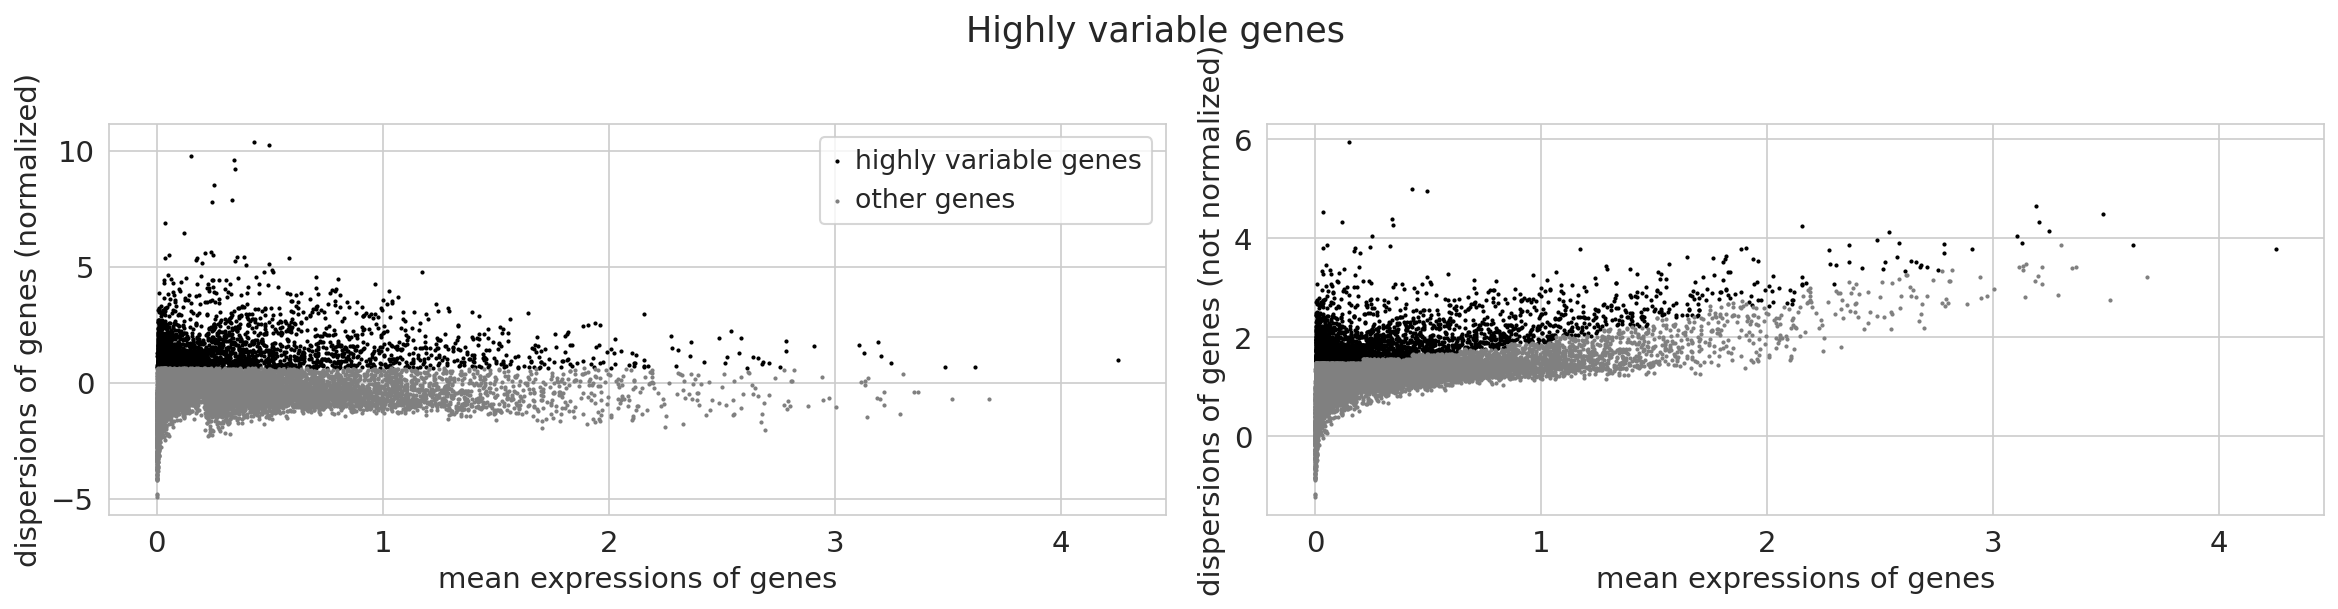


=== PCA variance explained ===


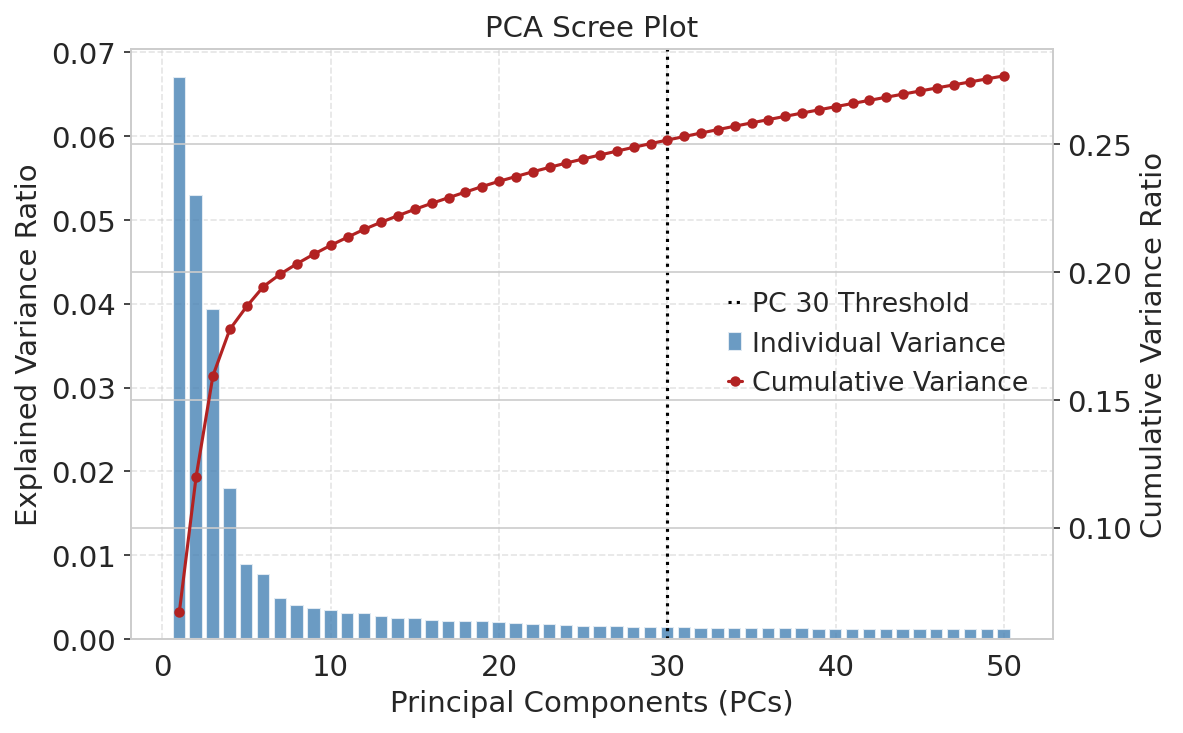


=== PCA colored by QC metrics ===


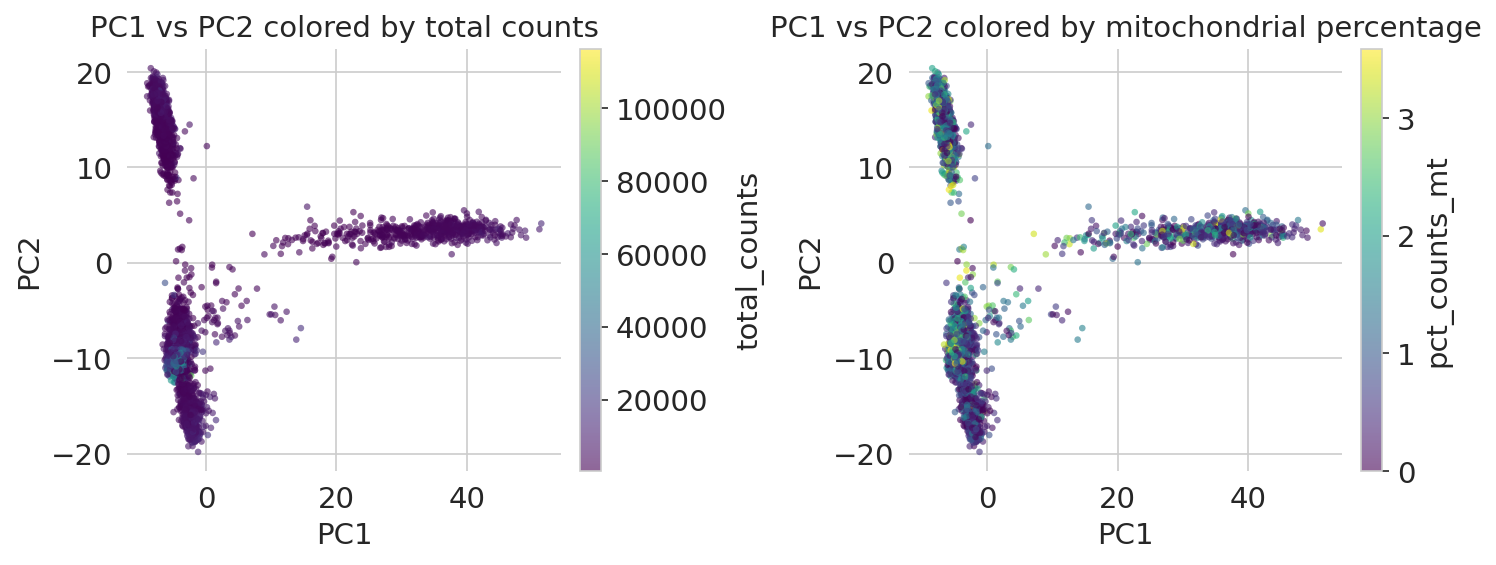

In [17]:
show_preprocess_plots()

In [18]:
create_review_packet("preprocess")

PosixPath('/mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/biology_review_packet.md')

In [19]:
print_reviewer_prompt("preprocess")

Use prompts/biology_reviewer.md as your reviewer instructions.

Please review this single-cell run using only the packet content below and any plots/screenshots I provide. Do not access data/ or inspect h5ad files directly unless I explicitly allow it.

## Preprocess Review Guidance

Please evaluate:

- Whether normalization and log1p look appropriate.
- Whether HVG selection looks reasonable.
- Whether PCA variance structure looks defensible.
- Whether technical effects remain visible in PCA.
- Whether Harmony or clustering can safely proceed.

# Biology Review Packet

- Review step: `preprocess`
- Run folder: `/mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408`
- Config path: `/mnt/12tb_dsk3/svitlana/scrna-agent/configs/pipeline.server.yaml`

## Current Parameters
- DATASET_ID: `EC`
- RUN_ID: `ec_debug`
- use_harmony: `True`
- harmony_batch_key: `individualID`
- hvg_n_top_genes: `3000`
- hvg_flavor: `seurat`
- leiden_resolution: `0.5`
- random_state: `42`
- debug_ma

## 6. Harmony

Harmony is optional batch correction. It is useful when there are multiple technical batches, donors, libraries, samples, or acquisition sources that plausibly introduce unwanted technical structure.

Harmony should not be used automatically just because metadata columns exist. It should be skipped when the selected batch key has fewer than 2 groups.

Disease, diagnosis, phenotype, treatment, outcome, age, sex, or other biological/clinical variables should not be used as Harmony batch keys unless explicitly justified. Brain region or tissue region can represent meaningful biology and should not automatically be corrected away.

The reviewer should check whether Harmony was justified and whether overcorrection risk exists before clustering.

In [23]:
run_step("harmony")

2026-05-11 09:45:37 INFO Running step 'harmony' in /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408
2026-05-11 09:45:37 INFO Loading intermediate /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/data/preprocessed.h5ad
2026-05-11 09:45:37 WARNING Running Harmony on X_pca using batch key individualID. Inspect results for possible overcorrection.
2026-05-11 09:45:37,317 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-05-11 09:45:37 INFO Running Harmony (PyTorch on cuda)
2026-05-11 09:45:37,317 - harmonypy - INFO -   Parameters:
2026-05-11 09:45:37 INFO   Parameters:
2026-05-11 09:45:37,317 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-11 09:45:37 INFO     max_iter_harmony: 10
2026-05-11 09:45:37,317 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-11 09:45:37 INFO     max_iter_kmeans: 20
2026-05-11 09:45:37,317 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-11 09:45:37 INFO     epsilon_cluster: 1e-05
2026-05-11 09:45

In [26]:
show_harmony_summary()

,harmony_enabled,harmony_ran,harmony_skipped,skip_reason,batch_key,n_batch_groups,batch_groups_preview,basis,basis_shape,adjusted_basis,adjusted_basis_shape,risky_batch_key_warning
0,True,True,False,NaN,individualID,46,R1924801; R8329066; R3292822; R6370138; R42601...,X_pca,"(4255, 50)",X_pca_harmony,"(4255, 50)",NaN


In [27]:
show_harmony_figures()

Latest run: /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408
No Harmony-related plot files found. Harmony plotting may be added later.


In [28]:
show_harmony_plots()

No Harmony plots are currently generated.


In [29]:
create_review_packet("harmony")

PosixPath('/mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/biology_review_packet.md')

In [30]:
print_reviewer_prompt("harmony")

Use prompts/biology_reviewer.md as your reviewer instructions.

Please review this single-cell run using only the packet content below and any plots/screenshots I provide. Do not access data/ or inspect h5ad files directly unless I explicitly allow it.

## Harmony Review Guidance

Please evaluate:

- Whether Harmony was justified for this dataset.
- Whether the selected batch key is appropriate.
- Whether the batch key might encode biological or clinical variation.
- Whether Harmony ran or was correctly skipped.
- Whether overcorrection risk should be checked before clustering.
- Whether clustering should use X_pca_harmony or original X_pca.

# Biology Review Packet

- Review step: `harmony`
- Run folder: `/mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408`
- Config path: `/mnt/12tb_dsk3/svitlana/scrna-agent/configs/pipeline.server.yaml`

## Current Parameters
- DATASET_ID: `EC`
- RUN_ID: `ec_debug`
- use_harmony: `True`
- harmony_batch_key: `individualID`
- hvg_n_top

## 7. Clustering

Clustering starts from `harmony.h5ad` when available, otherwise from `preprocessed.h5ad`.

Neighbors are computed using `X_pca_harmony` when Harmony ran and that embedding exists; otherwise neighbors use `X_pca`. This stage computes neighbors, UMAP, and Leiden clusters, then writes `clustered.h5ad`.

This stage does not run markers or assign cell type labels. The reviewer should inspect whether clusters and UMAP structure are technically and biologically plausible, and whether clusters appear driven by batch, QC metrics, or obvious artifacts.

Clustering parameters may require iterative tuning after reviewer inspection. Users may adjust `neighbors_n_neighbors`, `neighbors_n_pcs`, and `leiden_resolution`, then rerun `write_config()` and `run_step("cluster")`.

In [ ]:
run_step("cluster")

In [44]:
run_step("plots", context="cluster")

2026-05-11 11:56:52 INFO Running step 'plots' in /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408
2026-05-11 11:56:52 INFO Loading cluster plotting input from /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/data/clustered.h5ad
2026-05-11 11:56:53 INFO Writing plots intermediate to /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/data/plots.h5ad


In [45]:
show_clustering_summary()

,input_h5ad,cells,genes,neighbors_use_rep,n_neighbors,n_pcs,umap_random_state,clustering_method,leiden_resolution,clustering_key,n_clusters,cluster_sizes_preview,X_umap_present,X_umap_shape,X_pca_present,X_pca_harmony_present
0,/mnt/12tb_dsk3/svitlana/scrna-agent/results/ec...,4255,15519,X_pca_harmony,15,30,42,leiden,0.5,leiden,13,0:1409; 1:560; 10:18; 11:17; 12:17; 2:530; 3:5...,True,"(4255, 2)",True,True


In [48]:
show_clustering_figures()

Latest run: /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408
Clustering figure paths:
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/figures/umap_qc_counts_genes.png
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/figures/umap_leiden.png
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/figures/umap_leiden_numbered.png
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/figures/umap_metadata_panel.png



=== UMAP colored by counts and genes ===


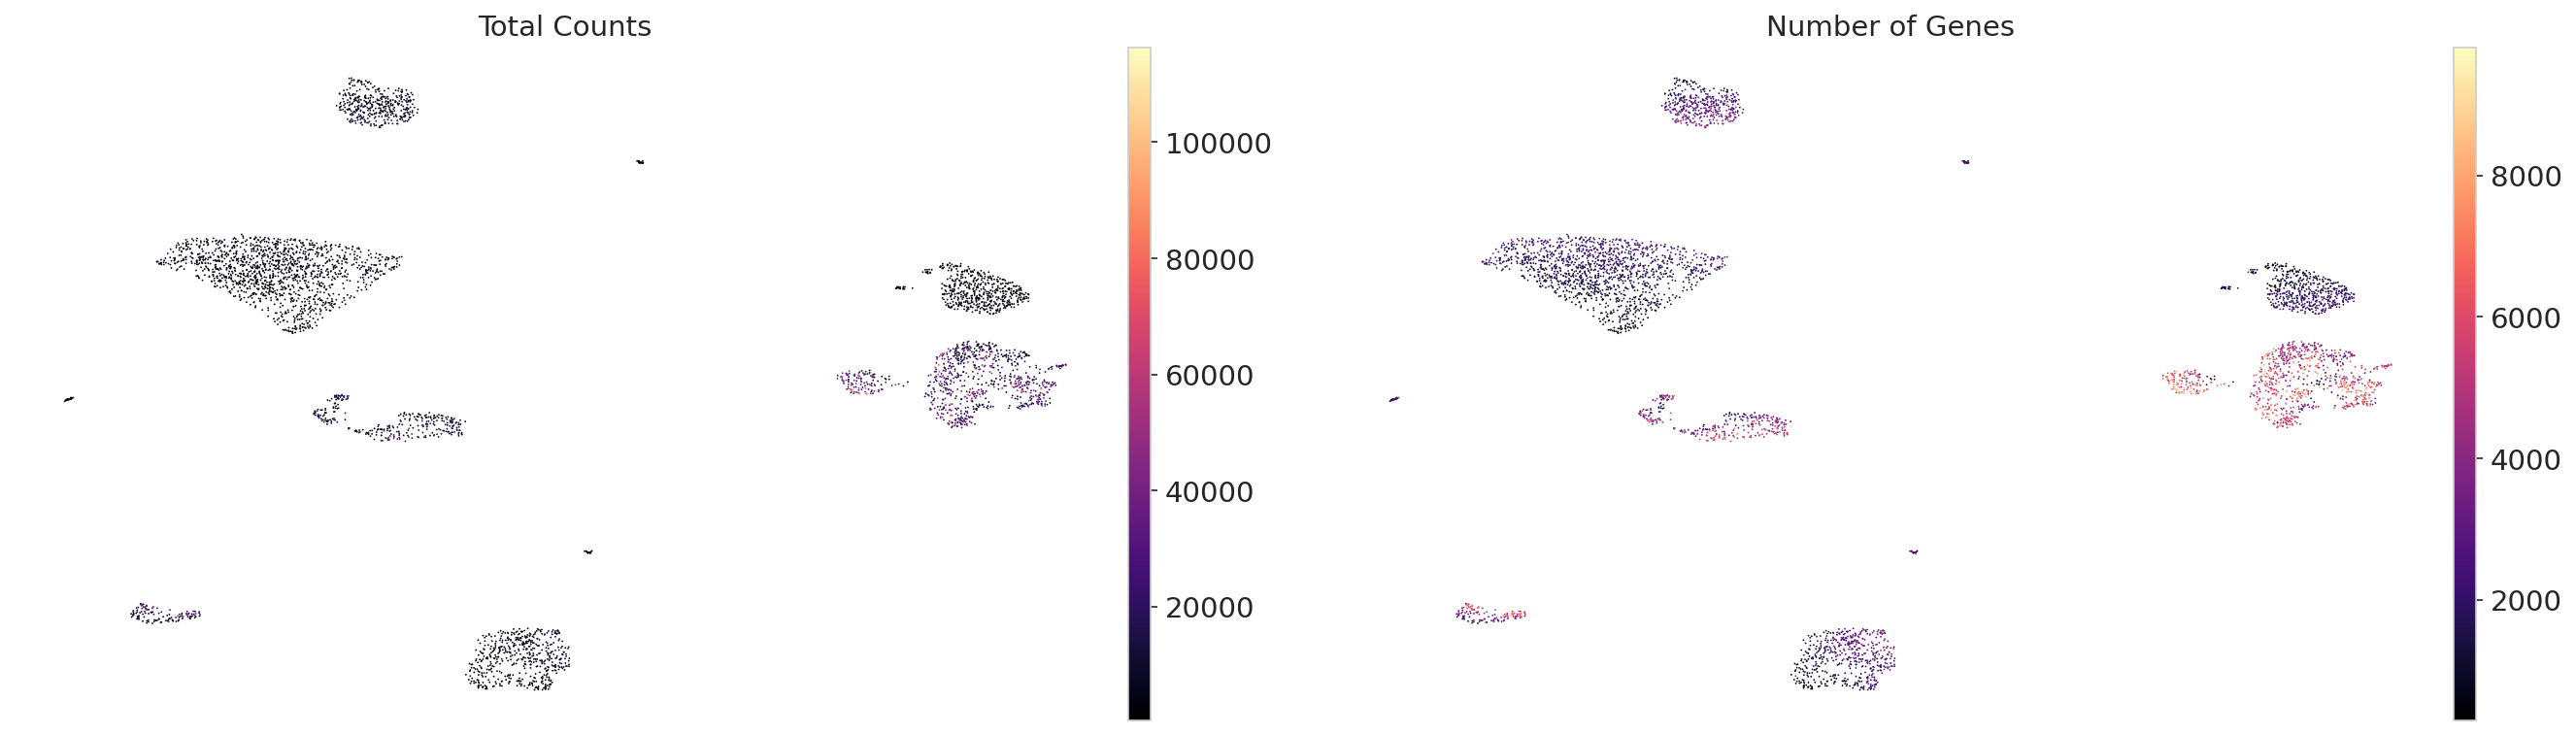


=== UMAP colored by Leiden clusters ===


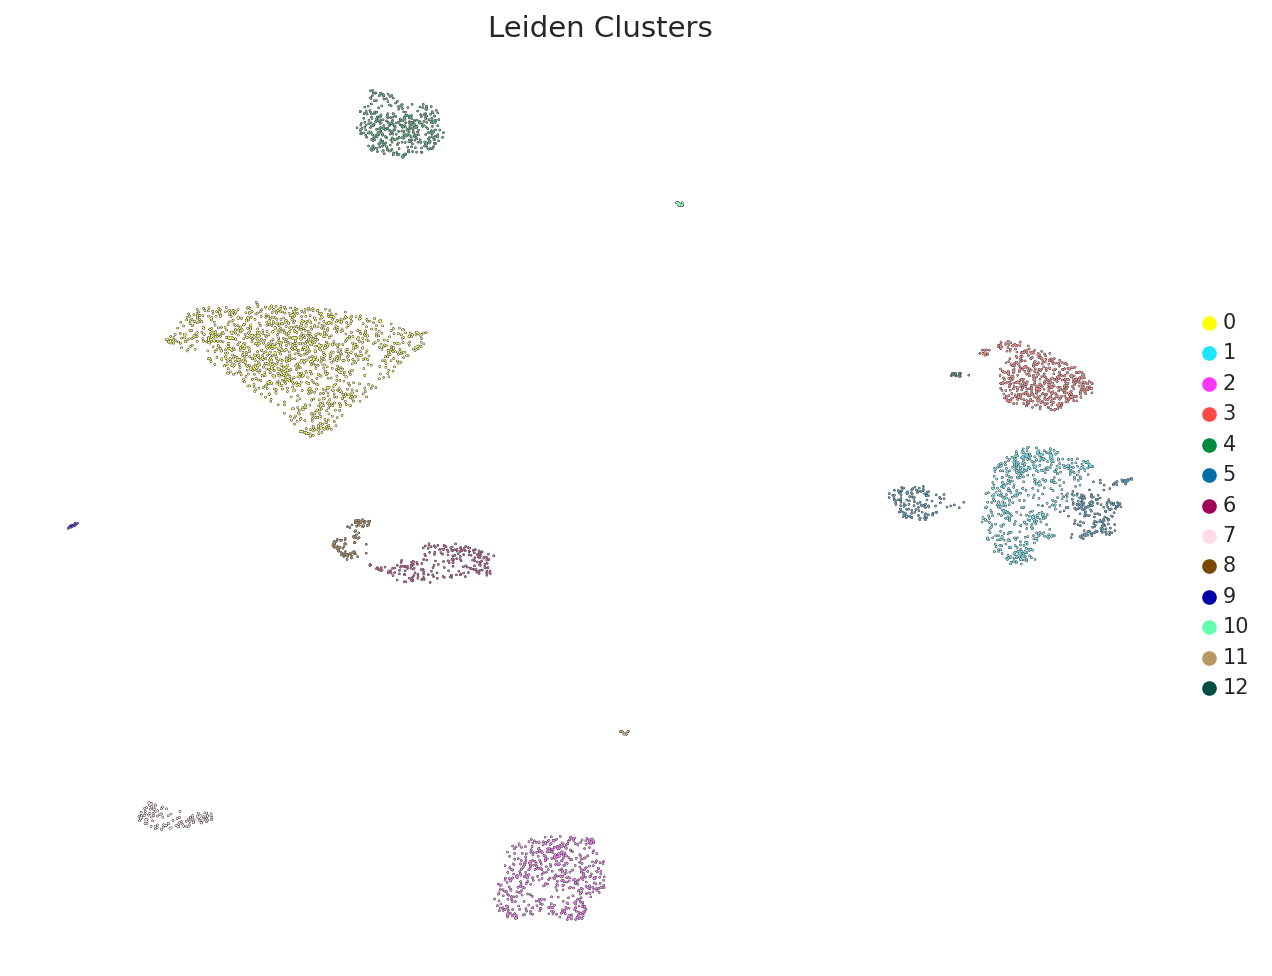


=== UMAP with Leiden labels on data ===


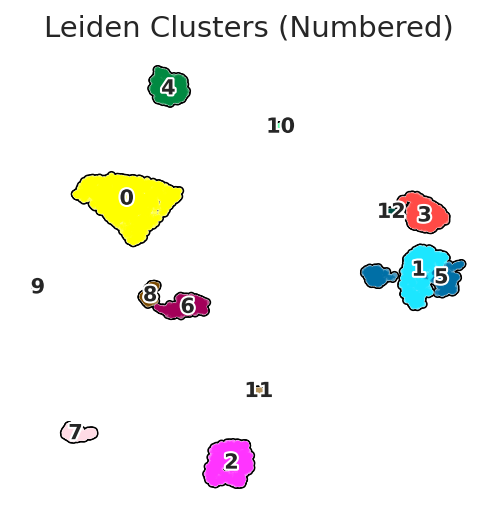


=== UMAP metadata sanity-check panel ===


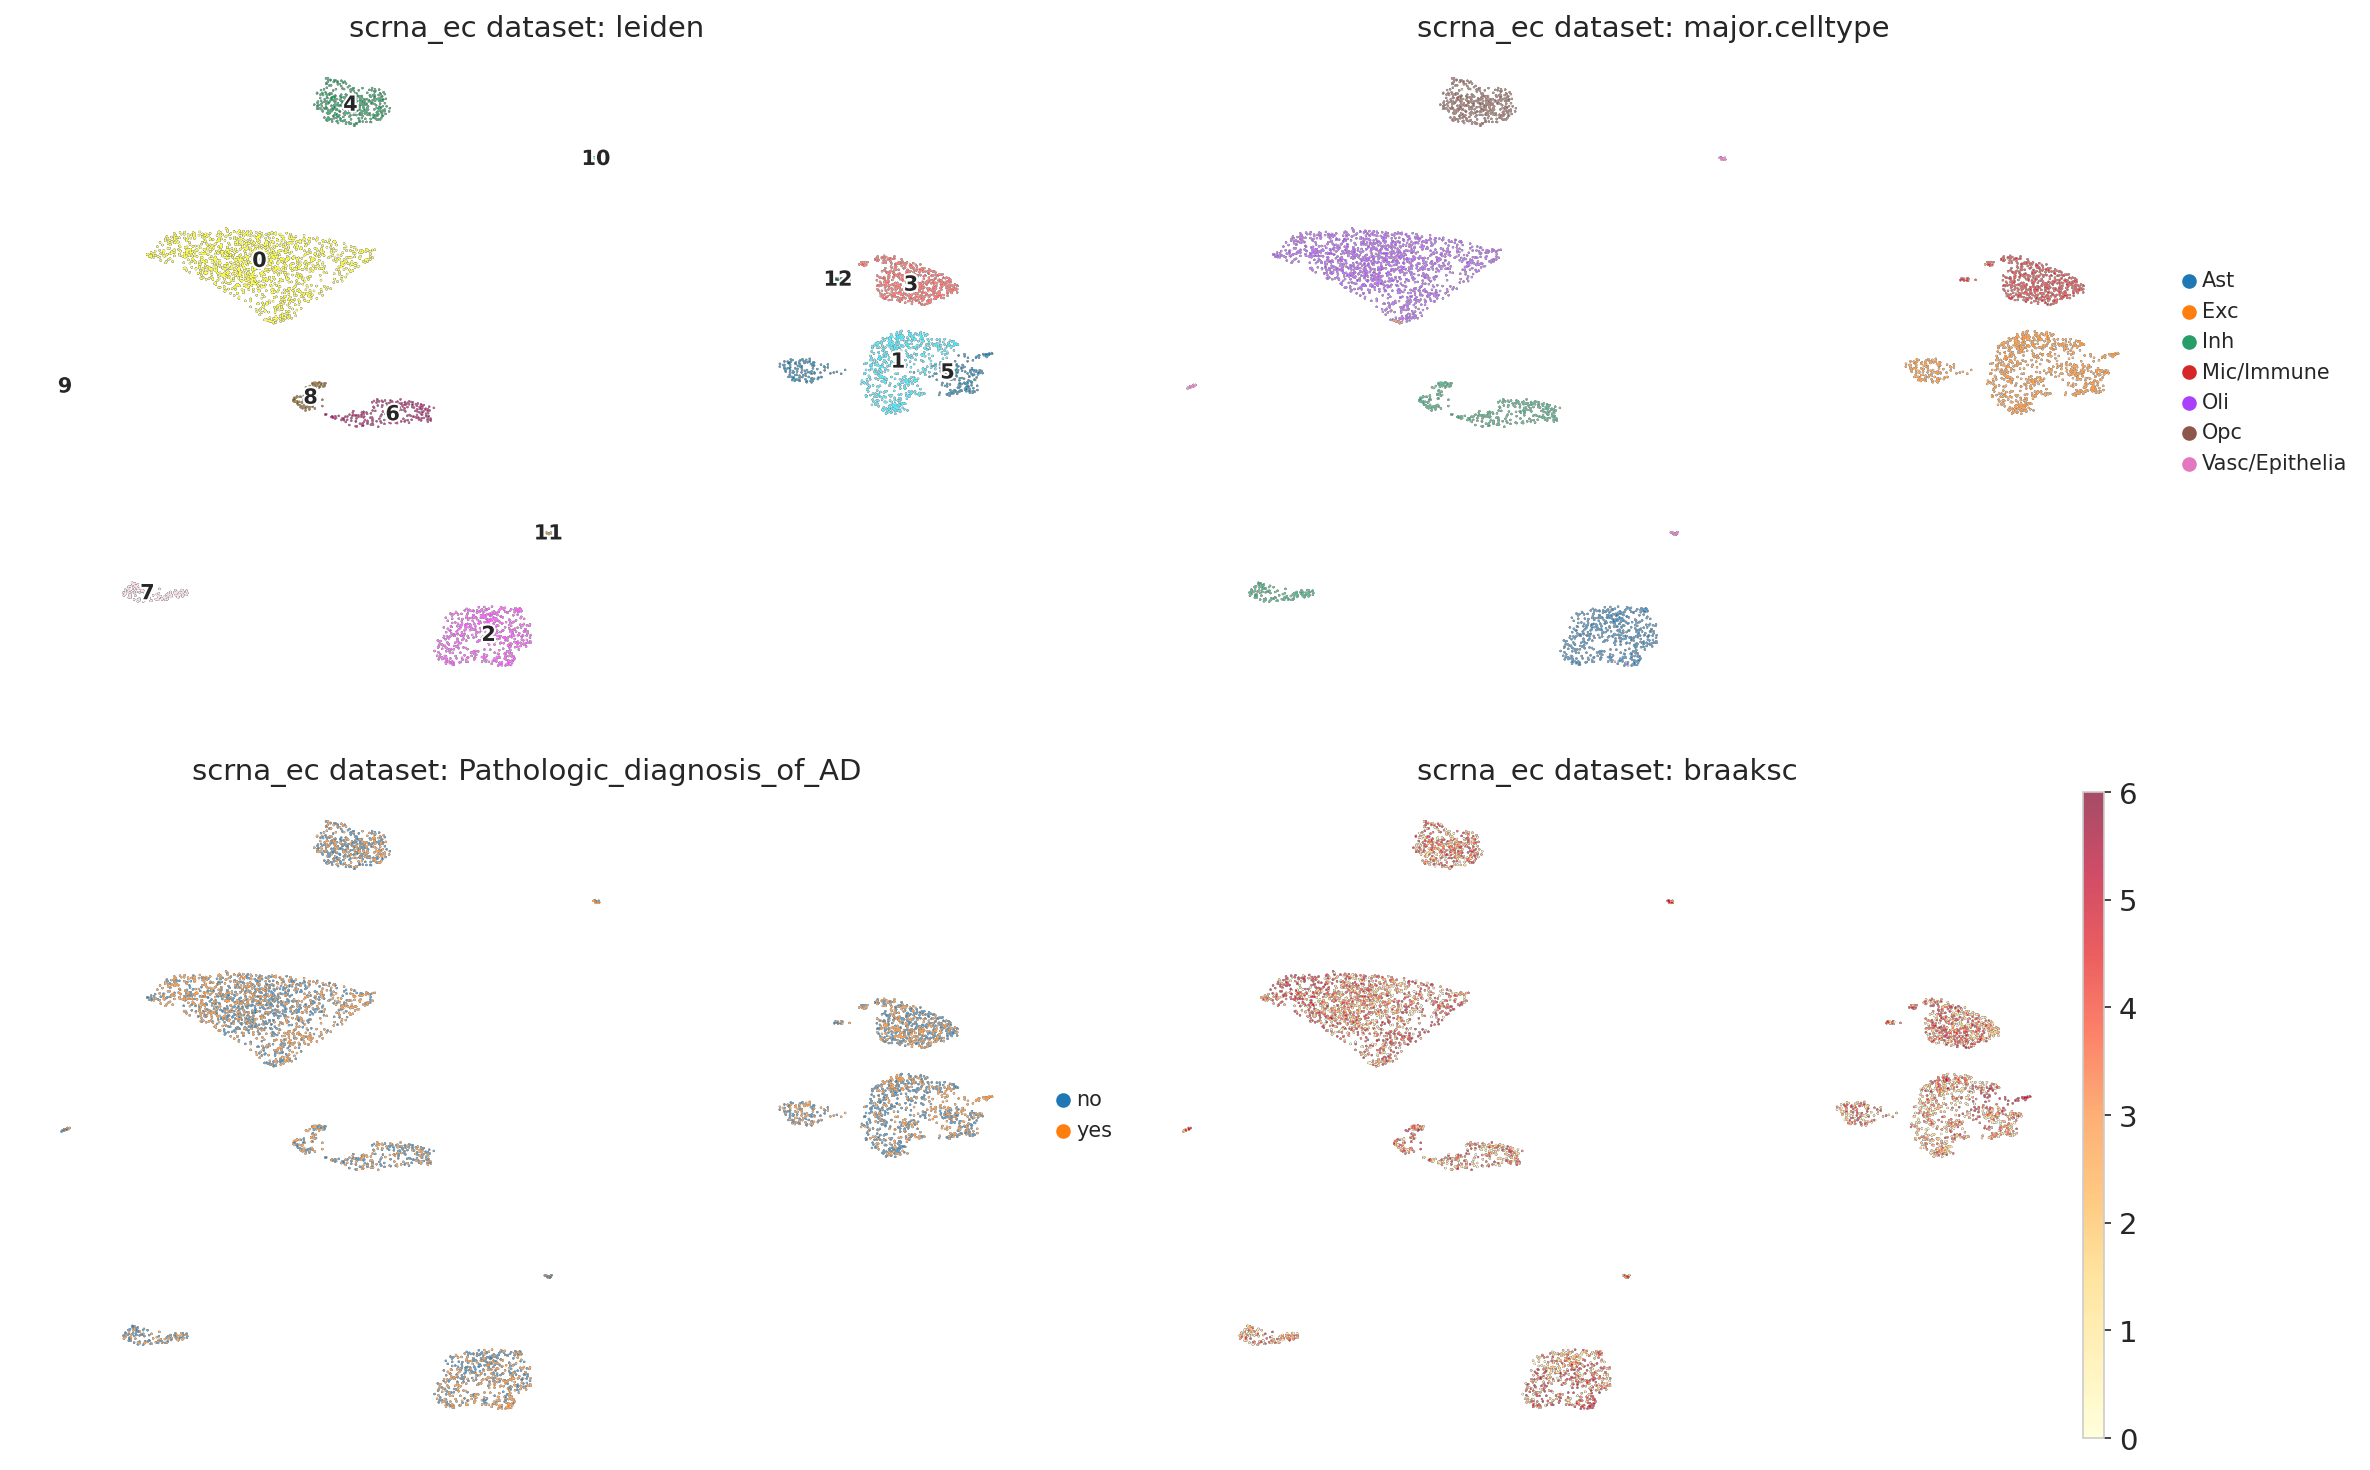

In [49]:
show_clustering_plots()

In [50]:
create_review_packet("cluster")

PosixPath('/mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/biology_review_packet.md')

In [51]:
print_reviewer_prompt("cluster")

Use prompts/biology_reviewer.md as your reviewer instructions.

Please review this single-cell run using only the packet content below and any plots/screenshots I provide. Do not access data/ or inspect h5ad files directly unless I explicitly allow it.

## Clustering Review Guidance

Please evaluate:

- Whether UMAP structure looks plausible.
- Whether Leiden resolution appears too coarse or too granular.
- Whether clusters appear driven by QC metrics.
- Whether Harmony may have overcorrected or undercorrected.
- Whether neighbor graph parameters should be adjusted.
- Whether Leiden resolution should be increased or decreased.
- Whether marker analysis can safely proceed.

# Biology Review Packet

- Review step: `cluster`
- Run folder: `/mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408`
- Config path: `/mnt/12tb_dsk3/svitlana/scrna-agent/configs/pipeline.server.yaml`

## Current Parameters
- DATASET_ID: `EC`
- RUN_ID: `ec_debug`
- use_harmony: `True`
- harmony_batch_

## 8. Markers

Markers are computed after clustering using Leiden clusters. Marker analysis helps assess cluster identity and quality, but this step does not automatically annotate clusters.

The reviewer should check marker plausibility before any manual annotation and should flag clusters that look low-quality, doublet-like, mixed, over-split, or under-split.

In [ ]:
run_step("markers")

In [78]:
run_step("plots", context="markers")

2026-05-11 14:41:41 INFO Running step 'plots' in /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408
2026-05-11 14:41:41 INFO Loading markers plotting input from /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/data/markers.h5ad
2026-05-11 14:41:42 INFO Writing plots intermediate to /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/data/plots.h5ad


In [74]:
show_marker_summary()

,input_h5ad,cells,genes,groupby,method,n_groups,groups,n_genes_requested,used_raw,marker_table_path
0,/mnt/12tb_dsk3/svitlana/scrna-agent/results/ec...,4255,15519,leiden,wilcoxon,13,0; 1; 10; 11; 12; 2; 3; 4; 5; 6; 7; 8; 9,100,True,/mnt/12tb_dsk3/svitlana/scrna-agent/results/ec...


In [75]:
show_marker_table()

,cluster,gene,rank,score,logfoldchange,pval,pval_adj
0,0,ST18,1,51.503063,8.824820,0.0,0.0
1,0,MBP,2,51.413570,4.916962,0.0,0.0
2,0,CTNNA3,3,51.158085,6.630686,0.0,0.0
3,0,PIP4K2A,4,50.900967,4.527424,0.0,0.0
4,0,SLC44A1,5,50.791214,4.512999,0.0,0.0
5,0,PLP1,6,50.782303,7.430964,0.0,0.0
6,0,RNF220,7,50.464424,6.194485,0.0,0.0
7,0,IL1RAPL1,8,49.926098,3.744780,0.0,0.0
8,0,TTLL7,9,49.815937,4.030784,0.0,0.0
9,0,SLC24A2,10,49.555504,4.433885,0.0,0.0


In [81]:
show_marker_figures()

Latest run: /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408
Marker figure paths:
- [FOUND] /mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/figures/marker_dotplot_top_genes.png



=== Marker dotplot top genes ===


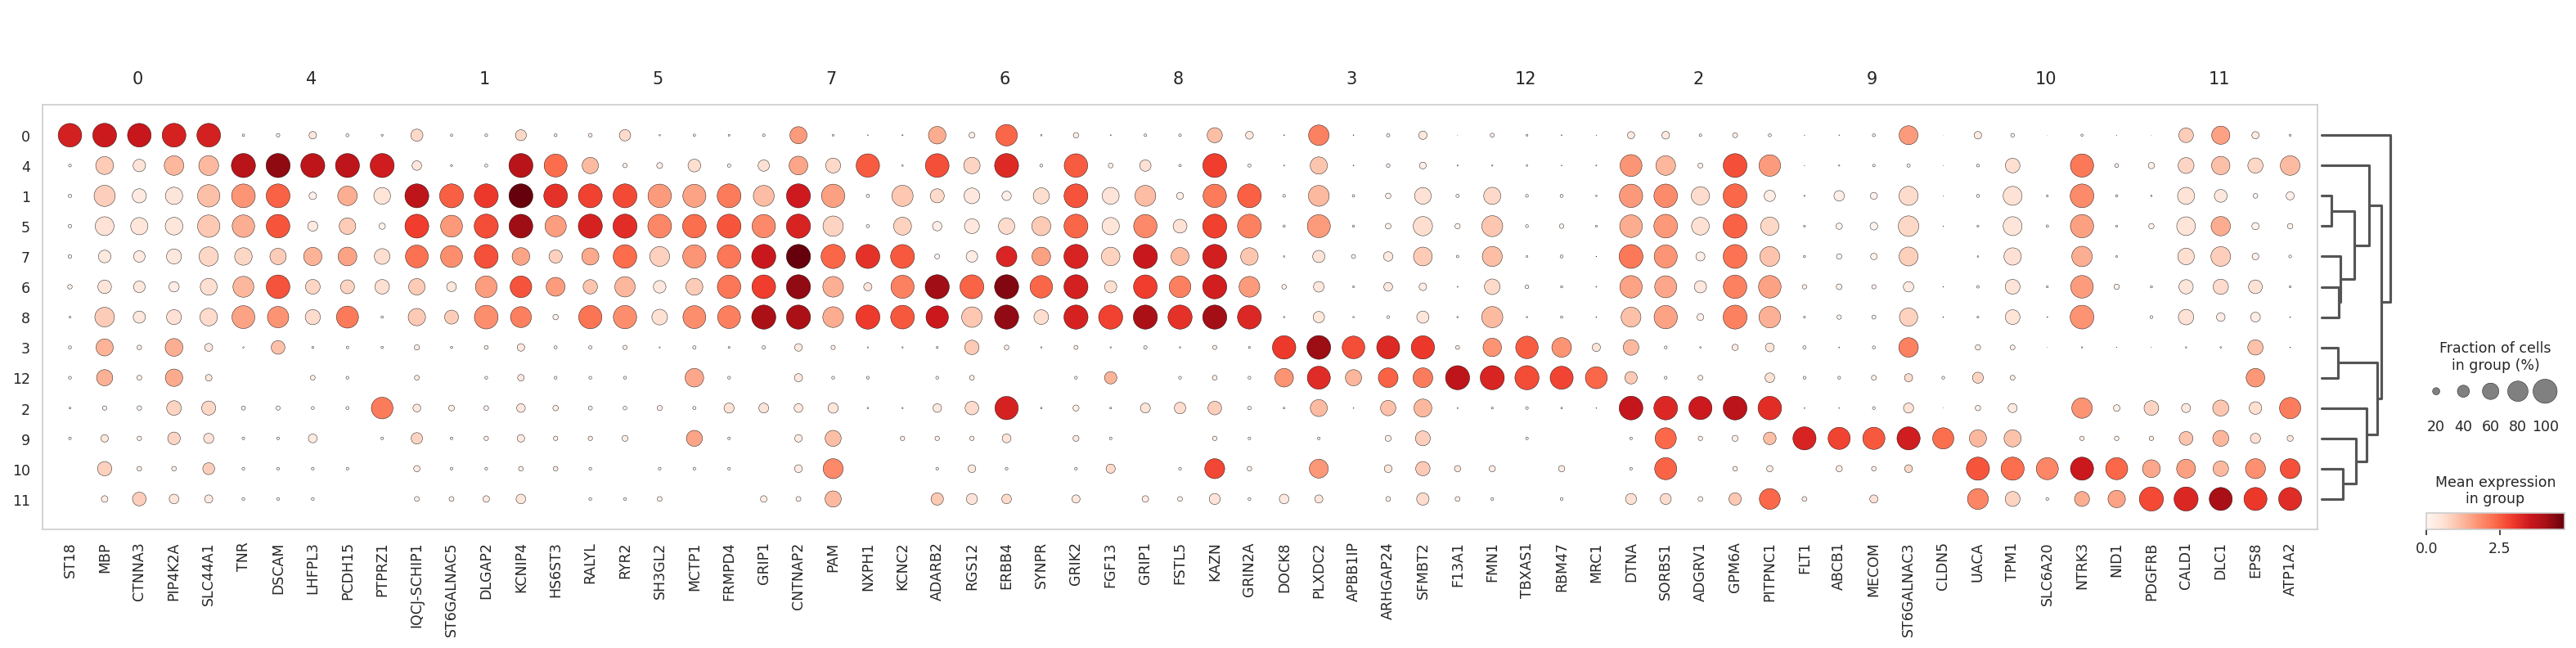

In [82]:
show_marker_plots()

In [86]:
create_review_packet("markers")

PosixPath('/mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408/biology_review_packet.md')

In [87]:
print_reviewer_prompt("markers")

Use prompts/biology_reviewer.md as your reviewer instructions.

Please review this single-cell run using only the packet content below and any plots/screenshots I provide. Do not access data/ or inspect h5ad files directly unless I explicitly allow it.

## Marker Review Guidance

Please evaluate:

- Whether marker genes look biologically plausible.
- Whether clusters appear well-separated by markers.
- Whether any clusters look low-quality, doublet-like, or mixed.
- Whether Leiden resolution should be adjusted.
- Whether manual annotation can be considered later.
- Whether any cluster should be merged, split, or rechecked.

# Biology Review Packet

- Review step: `markers`
- Run folder: `/mnt/12tb_dsk3/svitlana/scrna-agent/results/ec_debug_20260511_082408`
- Config path: `/mnt/12tb_dsk3/svitlana/scrna-agent/configs/pipeline.server.yaml`

## Current Parameters
- DATASET_ID: `EC`
- RUN_ID: `ec_debug`
- use_harmony: `True`
- harmony_batch_key: `individualID`
- neighbors_n_neighbors: `15`


## 9. Review Workflow

Use the review packet and reviewer prompt cells after each stage to inspect summaries, tables, and plots before continuing or changing parameters.

## 10. Optional UI Placeholder

This placeholder can be used for lightweight workflow status checks or future notebook UI controls.